# Fund Performance Analytics

This notebook computes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, benchmark comparison chart, and tracking error for 40 mutual fund schemes.

## Deliverables
- `fund_scorecard.csv`
- `alpha_beta.csv`
- `benchmark_comparison_top5.png`
- `tracking_error_top5.csv`
- `performance_summary.csv`


## 1. Imports and Folder Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress

# Project root fix
ROOT = Path.cwd()

# If notebook is opened from notebooks folder, move one level up
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
PERFORMANCE_DIR = REPORTS / "performance"
CHARTS_DIR = REPORTS / "charts"

PERFORMANCE_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", ROOT)
print("Performance Output Folder:", PERFORMANCE_DIR)
print("Charts Folder:", CHARTS_DIR)

Project Root: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics
Performance Output Folder: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance
Charts Folder: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts


## 2. Load NAV Data

In [2]:
nav_file = DATA_PROCESSED / "02_nav_history_clean.csv"
fund_master_file = DATA_PROCESSED / "01_fund_master_clean.csv"

nav_df = pd.read_csv(nav_file)
fund_master = pd.read_csv(fund_master_file)

# Clean column names
nav_df.columns = (
    nav_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

fund_master.columns = (
    fund_master.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Original NAV columns:")
print(nav_df.columns.tolist())

print("Fund Master columns:")
print(fund_master.columns.tolist())

# Merge NAV with fund master using amfi_code
nav_df = nav_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Clean values
nav_df["date"] = pd.to_datetime(nav_df["date"], dayfirst=True, errors="coerce")
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

nav_df = nav_df.dropna(subset=["date", "scheme_name", "nav"])
nav_df = nav_df.sort_values(["scheme_name", "date"])

print("Final NAV columns:")
print(nav_df.columns.tolist())

print("Total schemes:", nav_df["scheme_name"].nunique())
print("Date range:", nav_df["date"].min(), "to", nav_df["date"].max())

nav_df.head()

Original NAV columns:
['amfi_code', 'date', 'nav']
Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
Final NAV columns:
['amfi_code', 'date', 'nav', 'scheme_name']
Total schemes: 40
Date range: 2022-01-02 00:00:00 to 2026-12-05 00:00:00


,amfi_code,date,nav,scheme_name
32221,101206,2022-01-02,310.7970,ABSL Frontline Equity Fund - Regular - Growth
32241,101206,2022-01-03,311.0737,ABSL Frontline Equity Fund - Regular - Growth
32264,101206,2022-01-04,305.8097,ABSL Frontline Equity Fund - Regular - Growth
32307,101206,2022-01-06,306.2298,ABSL Frontline Equity Fund - Regular - Growth
32329,101206,2022-01-07,317.8039,ABSL Frontline Equity Fund - Regular - Growth


## 3. Daily Returns

In [3]:
nav_df["daily_return"] = nav_df.groupby("scheme_name")["nav"].pct_change()
returns_df = nav_df.dropna(subset=["daily_return"]).copy()

returns_summary = returns_df.groupby("scheme_name")["daily_return"].describe()
returns_summary.head()

,count,mean,std,min,25%,50%,75%,max
scheme_name,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,452.0,0.005129,0.077194,-0.298823,-0.022593,0.016103,0.049317,0.343622
ABSL Liquid Fund - Regular - Growth,452.0,0.000754,0.017828,-0.061089,0.004226,0.005713,0.008250,0.020224
ABSL Small Cap Fund - Regular - Growth,452.0,0.005166,0.094139,-0.316321,-0.050314,0.009124,0.064757,0.269619
Axis Bluechip Fund - Direct - Growth,452.0,0.003016,0.066959,-0.248909,-0.030880,0.003874,0.043533,0.202740
Axis Bluechip Fund - Regular - Growth,452.0,0.001885,0.051546,-0.166724,-0.023040,0.005670,0.034619,0.147914


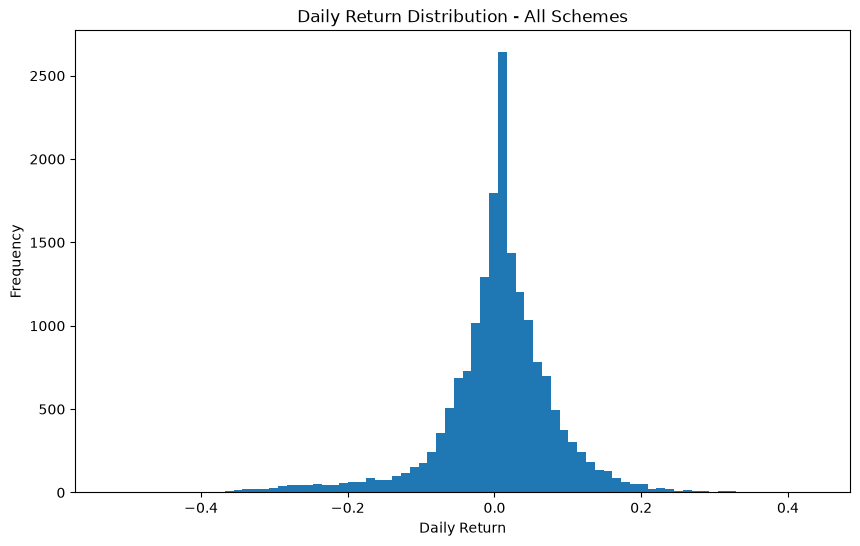

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts\daily_return_distribution.png


In [4]:
plt.figure(figsize=(10, 6))
returns_df["daily_return"].hist(bins=80)
plt.title("Daily Return Distribution - All Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(False)

dist_chart_path = CHARTS_DIR / "daily_return_distribution.png"
plt.savefig(dist_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", dist_chart_path)

## 4. CAGR for 1 Year, 3 Years, and 5 Years

In [5]:
def calculate_cagr(group, years):
    group = group.sort_values("date")
    end_date = group["date"].max()
    start_cutoff = end_date - pd.DateOffset(years=years)
    period_data = group[group["date"] >= start_cutoff]
    
    if len(period_data) < 2:
        return np.nan
    
    nav_start = period_data.iloc[0]["nav"]
    nav_end = period_data.iloc[-1]["nav"]
    actual_years = (period_data.iloc[-1]["date"] - period_data.iloc[0]["date"]).days / 365.25
    
    if actual_years <= 0 or nav_start <= 0:
        return np.nan
    
    return (nav_end / nav_start) ** (1 / actual_years) - 1


cagr_rows = []

for scheme, group in nav_df.groupby("scheme_name"):
    cagr_rows.append({
        "scheme_name": scheme,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_rows)
cagr_df.sort_values("cagr_3yr", ascending=False).head(10)

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
25,Mirae Asset Large Cap Fund - Regular - Growth,0.270145,0.374554,0.259173
18,ICICI Pru Midcap Fund - Regular - Growth,0.326660,0.347080,0.272482
5,Axis Midcap Fund - Regular - Growth,0.200992,0.335318,0.248352
22,Kotak Flexicap Fund - Regular - Growth,0.391748,0.327253,0.300310
8,DSP Small Cap Fund - Regular - Growth,0.839253,0.321227,0.318750
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.551741,0.321085,0.269420
15,ICICI Pru Bluechip Fund - Direct - Growth,0.199008,0.314388,0.199364
33,SBI Bluechip Fund - Regular Plan - Growth,0.716142,0.310344,0.231077
7,DSP Midcap Fund - Regular - Growth,0.240864,0.288392,0.255333
0,ABSL Frontline Equity Fund - Regular - Growth,0.482053,0.284195,0.202599


## 5. Sharpe Ratio

In [6]:
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252
daily_rf = RISK_FREE_RATE / TRADING_DAYS

sharpe_df = (
    returns_df.groupby("scheme_name")
    .agg(
        avg_daily_return=("daily_return", "mean"),
        std_daily_return=("daily_return", "std")
    )
    .reset_index()
)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["avg_daily_return"] - daily_rf) /
    sharpe_df["std_daily_return"]
) * np.sqrt(TRADING_DAYS)

sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)
sharpe_df.head(10)

,scheme_name,avg_daily_return,std_daily_return,sharpe_ratio
8,DSP Small Cap Fund - Regular - Growth,0.012396,0.128658,1.497615
36,SBI Small Cap Fund - Regular Plan - Growth,0.010577,0.124192,1.319043
22,Kotak Flexicap Fund - Regular - Growth,0.009137,0.107385,1.312585
25,Mirae Asset Large Cap Fund - Regular - Growth,0.008372,0.100002,1.288039
18,ICICI Pru Midcap Fund - Regular - Growth,0.009052,0.108553,1.286059
7,DSP Midcap Fund - Regular - Growth,0.008352,0.103565,1.240708
5,Axis Midcap Fund - Regular - Growth,0.008314,0.103393,1.236959
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.006758,0.087616,1.177718
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.007025,0.092877,1.156707
33,SBI Bluechip Fund - Regular Plan - Growth,0.006354,0.084946,1.139130


## 6. Sortino Ratio

In [7]:
def downside_std(x):
    downside_returns = x[x < 0]
    if len(downside_returns) == 0:
        return np.nan
    return downside_returns.std()


sortino_df = (
    returns_df.groupby("scheme_name")
    .agg(
        avg_daily_return=("daily_return", "mean"),
        downside_std=("daily_return", downside_std)
    )
    .reset_index()
)

sortino_df["sortino_ratio"] = (
    (sortino_df["avg_daily_return"] - daily_rf) /
    sortino_df["downside_std"]
) * np.sqrt(TRADING_DAYS)

sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)
sortino_df.head(10)

,scheme_name,avg_daily_return,downside_std,sortino_ratio
36,SBI Small Cap Fund - Regular Plan - Growth,0.010577,0.088632,1.848268
8,DSP Small Cap Fund - Regular - Growth,0.012396,0.106669,1.806345
31,Nippon India Small Cap Fund - Regular - Growth,0.006700,0.063686,1.605662
35,SBI Small Cap Fund - Direct Plan - Growth,0.006623,0.070219,1.438918
22,Kotak Flexicap Fund - Regular - Growth,0.009137,0.098978,1.424086
7,DSP Midcap Fund - Regular - Growth,0.008352,0.090607,1.418146
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.007025,0.077833,1.380275
18,ICICI Pru Midcap Fund - Regular - Growth,0.009052,0.101550,1.374746
5,Axis Midcap Fund - Regular - Growth,0.008314,0.096052,1.331506
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.006758,0.081696,1.263067


## 7. Load Benchmark Data

In [8]:
benchmark_file = DATA_PROCESSED / "10_benchmark_indices_clean.csv"

benchmark_df = pd.read_csv(benchmark_file)

benchmark_df.columns = (
    benchmark_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Original Benchmark Columns:")
print(benchmark_df.columns.tolist())

print("Benchmark index names:")
print(benchmark_df["index_name"].unique())

# Rename close_value to value
benchmark_df = benchmark_df.rename(columns={
    "close_value": "value"
})

# Clean date and value
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"], dayfirst=True, errors="coerce")
benchmark_df["value"] = pd.to_numeric(benchmark_df["value"], errors="coerce")

benchmark_df = benchmark_df.dropna(subset=["date", "index_name", "value"])

# Clean index names for easier matching
benchmark_df["index_name_clean"] = (
    benchmark_df["index_name"]
    .astype(str)
    .str.lower()
    .str.replace(" ", "")
    .str.replace("_", "")
    .str.replace("-", "")
)

# Create benchmark type column
def identify_benchmark(name):
    if "50" in name and "nifty" in name:
        return "nifty50"
    elif "100" in name and "nifty" in name:
        return "nifty100"
    else:
        return None

benchmark_df["benchmark_type"] = benchmark_df["index_name_clean"].apply(identify_benchmark)

benchmark_df = benchmark_df.dropna(subset=["benchmark_type"])

# Pivot long format to wide format
benchmark_df = benchmark_df.pivot_table(
    index="date",
    columns="benchmark_type",
    values="value",
    aggfunc="last"
).reset_index()

# Remove column index name
benchmark_df.columns.name = None

print("Final Benchmark Columns:")
print(benchmark_df.columns.tolist())

# Check required columns
if "nifty50" not in benchmark_df.columns:
    raise KeyError("nifty50 not found. Check index_name values printed above.")

if "nifty100" not in benchmark_df.columns:
    raise KeyError("nifty100 not found. Check index_name values printed above.")

benchmark_df = benchmark_df.sort_values("date")

benchmark_df["nifty50_return"] = benchmark_df["nifty50"].pct_change()
benchmark_df["nifty100_return"] = benchmark_df["nifty100"].pct_change()

benchmark_df.head()

Original Benchmark Columns:
['date', 'index_name', 'close_value']
Benchmark index names:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str
Final Benchmark Columns:
['date', 'nifty100', 'nifty50']


,date,nifty100,nifty50,nifty50_return,nifty100_return
0,2022-01-02,18101.19,14936.51,NaN,NaN
1,2022-01-03,17708.25,14639.75,-0.019868,-0.021708
2,2022-01-04,18832.60,14685.66,0.003136,0.063493
3,2022-01-06,19410.05,15353.40,0.045469,0.030662
4,2022-01-07,19719.91,16874.78,0.099091,0.015964


## 8. Alpha and Beta using Nifty 100

In [9]:
alpha_beta_rows = []

for scheme, group in returns_df.groupby("scheme_name"):
    merged = pd.merge(
        group[["date", "daily_return"]],
        benchmark_df[["date", "nifty100_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    if len(merged) < 30:
        alpha = np.nan
        beta = np.nan
        r_squared = np.nan
    else:
        result = linregress(
            merged["nifty100_return"],
            merged["daily_return"]
        )
        beta = result.slope
        alpha = result.intercept * TRADING_DAYS
        r_squared = result.rvalue ** 2
    
    alpha_beta_rows.append({
        "scheme_name": scheme,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_squared
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)

alpha_beta_path = PERFORMANCE_DIR / "alpha_beta.csv"
alpha_beta_df.to_csv(alpha_beta_path, index=False)

print("Saved:", alpha_beta_path)
alpha_beta_df.head(10)

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\alpha_beta.csv


,scheme_name,alpha,beta,r_squared
8,DSP Small Cap Fund - Regular - Growth,2.844599,0.524358,0.069448
22,Kotak Flexicap Fund - Regular - Growth,2.398861,-0.180934,0.011869
36,SBI Small Cap Fund - Regular Plan - Growth,2.305813,0.675700,0.123766
25,Mirae Asset Large Cap Fund - Regular - Growth,2.264867,-0.291450,0.035514
7,DSP Midcap Fund - Regular - Growth,2.200982,-0.180754,0.012736
5,Axis Midcap Fund - Regular - Growth,2.191437,-0.180719,0.012773
18,ICICI Pru Midcap Fund - Regular - Growth,2.162711,0.222543,0.017572
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.864050,-0.302467,0.049827
26,Mirae Asset Tax Saver Fund - Regular - Growth,1.777376,-0.013080,0.000083
31,Nippon India Small Cap Fund - Regular - Growth,1.764114,-0.142439,0.008896


## 9. Maximum Drawdown and Date Range

In [10]:
drawdown_rows = []

for scheme, group in nav_df.groupby("scheme_name"):
    group = group.sort_values("date").copy()
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1
    
    trough_idx = group["drawdown"].idxmin()
    trough_date = group.loc[trough_idx, "date"]
    max_drawdown = group.loc[trough_idx, "drawdown"]
    
    peak_data = group.loc[:trough_idx]
    peak_idx = peak_data["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]
    
    drawdown_rows.append({
        "scheme_name": scheme,
        "max_drawdown": max_drawdown,
        "drawdown_start_date": peak_date,
        "drawdown_end_date": trough_date
    })

drawdown_df = pd.DataFrame(drawdown_rows)
drawdown_df = drawdown_df.sort_values("max_drawdown")
drawdown_df.head(10)

,scheme_name,max_drawdown,drawdown_start_date,drawdown_end_date
8,DSP Small Cap Fund - Regular - Growth,-0.523526,2025-02-12,2025-03-01
6,Axis Small Cap Fund - Regular - Growth,-0.498422,2025-08-05,2026-11-05
35,SBI Small Cap Fund - Direct Plan - Growth,-0.497372,2023-11-01,2025-10-10
36,SBI Small Cap Fund - Regular Plan - Growth,-0.433908,2023-03-10,2023-10-01
7,DSP Midcap Fund - Regular - Growth,-0.428700,2023-02-10,2023-10-02
25,Mirae Asset Large Cap Fund - Regular - Growth,-0.408232,2024-10-12,2024-11-01
5,Axis Midcap Fund - Regular - Growth,-0.381816,2024-11-11,2024-12-02
18,ICICI Pru Midcap Fund - Regular - Growth,-0.377792,2022-02-12,2022-04-01
33,SBI Bluechip Fund - Regular Plan - Growth,-0.372071,2025-09-12,2025-10-01
22,Kotak Flexicap Fund - Regular - Growth,-0.365886,2024-02-12,2024-05-02


## 10. Load Expense Ratio Data

In [11]:
expense_file = DATA_PROCESSED / "01_fund_master_clean.csv"

expense_df = pd.read_csv(expense_file)

expense_df.columns = (
    expense_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

expense_df = expense_df.rename(columns={
    "expense_ratio_pct": "expense_ratio"
})

expense_df["expense_ratio"] = pd.to_numeric(expense_df["expense_ratio"], errors="coerce")

expense_df = expense_df[["scheme_name", "expense_ratio"]].drop_duplicates()

expense_df.head()

,scheme_name,expense_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,1.54
1,SBI Bluechip Fund - Direct Plan - Growth,0.66
2,SBI Small Cap Fund - Regular Plan - Growth,1.43
3,SBI Small Cap Fund - Direct Plan - Growth,0.72
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77


## 11. Fund Scorecard

In [12]:
scorecard_df = (
    cagr_df
    .merge(sharpe_df[["scheme_name", "sharpe_ratio"]], on="scheme_name", how="left")
    .merge(sortino_df[["scheme_name", "sortino_ratio"]], on="scheme_name", how="left")
    .merge(alpha_beta_df[["scheme_name", "alpha", "beta", "r_squared"]], on="scheme_name", how="left")
    .merge(drawdown_df, on="scheme_name", how="left")
    .merge(expense_df, on="scheme_name", how="left")
)

def percentile_score(series, higher_better=True):
    if higher_better:
        return series.rank(pct=True) * 100
    return series.rank(pct=True, ascending=False) * 100


scorecard_df["return_3yr_score"] = percentile_score(scorecard_df["cagr_3yr"], higher_better=True)
scorecard_df["sharpe_score"] = percentile_score(scorecard_df["sharpe_ratio"], higher_better=True)
scorecard_df["alpha_score"] = percentile_score(scorecard_df["alpha"], higher_better=True)
scorecard_df["expense_score"] = percentile_score(scorecard_df["expense_ratio"], higher_better=False)
scorecard_df["drawdown_score"] = percentile_score(scorecard_df["max_drawdown"], higher_better=True)

scorecard_df["fund_score"] = (
    0.30 * scorecard_df["return_3yr_score"] +
    0.25 * scorecard_df["sharpe_score"] +
    0.20 * scorecard_df["alpha_score"] +
    0.15 * scorecard_df["expense_score"] +
    0.10 * scorecard_df["drawdown_score"]
)

scorecard_df["fund_score"] = scorecard_df["fund_score"].round(2)
scorecard_df = scorecard_df.sort_values("fund_score", ascending=False)

fund_scorecard_path = PERFORMANCE_DIR / "fund_scorecard.csv"
scorecard_df.to_csv(fund_scorecard_path, index=False)

print("Saved:", fund_scorecard_path)
scorecard_df.head(10)

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\fund_scorecard.csv


,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,drawdown_start_date,drawdown_end_date,expense_ratio,return_3yr_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
22,Kotak Flexicap Fund - Regular - Growth,0.391748,0.327253,0.300310,1.312585,1.424086,2.398861,-0.180934,0.011869,-0.365886,2024-02-12,2024-05-02,1.45,92.5,95.0,97.5,47.50,25.0,80.62
18,ICICI Pru Midcap Fund - Regular - Growth,0.326660,0.347080,0.272482,1.286059,1.374746,2.162711,0.222543,0.017572,-0.377792,2022-02-12,2022-04-01,1.36,97.5,90.0,85.0,65.00,20.0,80.50
25,Mirae Asset Large Cap Fund - Regular - Growth,0.270145,0.374554,0.259173,1.288039,1.072502,2.264867,-0.291450,0.035514,-0.408232,2024-10-12,2024-11-01,1.46,100.0,92.5,92.5,45.00,15.0,79.88
5,Axis Midcap Fund - Regular - Growth,0.200992,0.335318,0.248352,1.236959,1.331506,2.191437,-0.180719,0.012773,-0.381816,2024-11-11,2024-12-02,1.38,95.0,85.0,87.5,60.00,17.5,78.00
8,DSP Small Cap Fund - Regular - Growth,0.839253,0.321227,0.318750,1.497615,1.806345,2.844599,0.524358,0.069448,-0.523526,2025-02-12,2025-03-01,1.52,90.0,100.0,100.0,36.25,2.5,77.69
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.551741,0.321085,0.269420,1.177718,1.263067,1.864050,-0.302467,0.049827,-0.334540,2024-01-11,2024-11-01,1.38,87.5,82.5,82.5,60.00,35.0,75.88
36,SBI Small Cap Fund - Regular Plan - Growth,0.944528,0.274069,0.254433,1.319043,1.848268,2.305813,0.675700,0.123766,-0.433908,2023-03-10,2023-10-01,1.43,75.0,97.5,95.0,50.00,10.0,74.38
15,ICICI Pru Bluechip Fund - Direct - Growth,0.199008,0.314388,0.199364,1.027680,1.109686,1.298061,0.198166,0.024389,-0.268692,2023-04-12,2023-05-06,0.80,85.0,67.5,57.5,72.50,62.5,71.00
7,DSP Midcap Fund - Regular - Growth,0.240864,0.288392,0.255333,1.240708,1.418146,2.200982,-0.180754,0.012736,-0.428700,2023-02-10,2023-10-02,1.61,80.0,87.5,90.0,7.50,12.5,66.25
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.329586,0.258774,0.253317,1.156707,1.380275,1.777376,-0.013080,0.000083,-0.283470,2022-06-12,2022-11-03,1.60,72.5,80.0,80.0,11.25,57.5,65.19


## 12. Benchmark Comparison Chart

In [13]:
top_5_funds = scorecard_df.head(5)["scheme_name"].tolist()
print("Top 5 Funds:")
top_5_funds

Top 5 Funds:


['Kotak Flexicap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth',
 'Axis Midcap Fund - Regular - Growth',
 'DSP Small Cap Fund - Regular - Growth']

In [14]:
end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

fund_chart_df = nav_df[
    (nav_df["scheme_name"].isin(top_5_funds)) &
    (nav_df["date"] >= start_date)
].copy()

fund_chart_df["normalized_value"] = (
    fund_chart_df.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_chart_df = benchmark_df[benchmark_df["date"] >= start_date].copy()

benchmark_chart_df["nifty50_normalized"] = (
    benchmark_chart_df["nifty50"] / benchmark_chart_df["nifty50"].iloc[0] * 100
)

benchmark_chart_df["nifty100_normalized"] = (
    benchmark_chart_df["nifty100"] / benchmark_chart_df["nifty100"].iloc[0] * 100
)

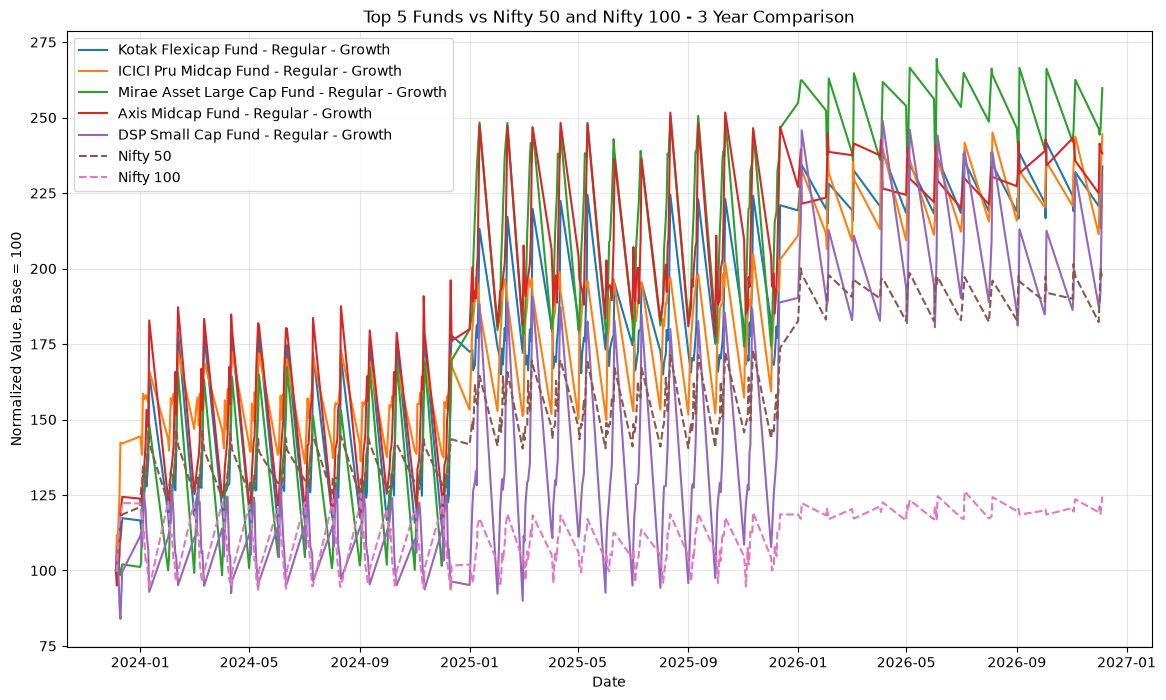

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts\benchmark_comparison_top5.png


In [15]:
plt.figure(figsize=(14, 8))

for scheme in top_5_funds:
    temp = fund_chart_df[fund_chart_df["scheme_name"] == scheme]
    plt.plot(temp["date"], temp["normalized_value"], label=scheme)

plt.plot(
    benchmark_chart_df["date"],
    benchmark_chart_df["nifty50_normalized"],
    linestyle="--",
    label="Nifty 50"
)

plt.plot(
    benchmark_chart_df["date"],
    benchmark_chart_df["nifty100_normalized"],
    linestyle="--",
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 50 and Nifty 100 - 3 Year Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Value, Base = 100")
plt.legend()
plt.grid(True, alpha=0.3)

benchmark_chart_path = CHARTS_DIR / "benchmark_comparison_top5.png"
plt.savefig(benchmark_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", benchmark_chart_path)

## 13. Tracking Error

In [16]:
tracking_rows = []

for scheme in top_5_funds:
    fund_returns = returns_df[
        (returns_df["scheme_name"] == scheme) &
        (returns_df["date"] >= start_date)
    ][["date", "daily_return"]]
    
    merged = pd.merge(
        fund_returns,
        benchmark_df[["date", "nifty50_return", "nifty100_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    if len(merged) < 30:
        te_nifty50 = np.nan
        te_nifty100 = np.nan
    else:
        te_nifty50 = (
            (merged["daily_return"] - merged["nifty50_return"]).std()
            * np.sqrt(TRADING_DAYS)
        )
        
        te_nifty100 = (
            (merged["daily_return"] - merged["nifty100_return"]).std()
            * np.sqrt(TRADING_DAYS)
        )
    
    tracking_rows.append({
        "scheme_name": scheme,
        "tracking_error_nifty50": te_nifty50,
        "tracking_error_nifty100": te_nifty100
    })

tracking_error_df = pd.DataFrame(tracking_rows)

tracking_error_path = PERFORMANCE_DIR / "tracking_error_top5.csv"
tracking_error_df.to_csv(tracking_error_path, index=False)

print("Saved:", tracking_error_path)
tracking_error_df

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\tracking_error_top5.csv


,scheme_name,tracking_error_nifty50,tracking_error_nifty100
0,Kotak Flexicap Fund - Regular - Growth,1.475686,2.355044
1,ICICI Pru Midcap Fund - Regular - Growth,1.024046,1.908033
2,Mirae Asset Large Cap Fund - Regular - Growth,1.545844,2.468781
3,Axis Midcap Fund - Regular - Growth,1.381517,2.348577
4,DSP Small Cap Fund - Regular - Growth,2.118166,2.082221


## 14. Final Performance Summary

In [17]:
final_summary = scorecard_df[[
    "scheme_name",
    "fund_score",
    "cagr_1yr",
    "cagr_3yr",
    "cagr_5yr",
    "sharpe_ratio",
    "sortino_ratio",
    "alpha",
    "beta",
    "max_drawdown",
    "expense_ratio",
    "drawdown_start_date",
    "drawdown_end_date"
]].copy()

percentage_cols = ["cagr_1yr", "cagr_3yr", "cagr_5yr", "alpha", "max_drawdown"]

for col in percentage_cols:
    final_summary[col] = final_summary[col] * 100

# Round only numeric columns
numeric_cols = final_summary.select_dtypes(include=["number"]).columns
final_summary[numeric_cols] = final_summary[numeric_cols].round(2)

# Format dates clearly
final_summary["drawdown_start_date"] = pd.to_datetime(
    final_summary["drawdown_start_date"], errors="coerce"
).dt.strftime("%Y-%m-%d")

final_summary["drawdown_end_date"] = pd.to_datetime(
    final_summary["drawdown_end_date"], errors="coerce"
).dt.strftime("%Y-%m-%d")

final_summary_path = PERFORMANCE_DIR / "performance_summary.csv"
final_summary.to_csv(final_summary_path, index=False)

print("Saved:", final_summary_path)
final_summary.head(15)

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\performance_summary.csv


,scheme_name,fund_score,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,expense_ratio,drawdown_start_date,drawdown_end_date
22,Kotak Flexicap Fund - Regular - Growth,80.62,39.17,32.73,30.03,1.31,1.42,239.89,-0.18,-36.59,1.45,2024-02-12,2024-05-02
18,ICICI Pru Midcap Fund - Regular - Growth,80.50,32.67,34.71,27.25,1.29,1.37,216.27,0.22,-37.78,1.36,2022-02-12,2022-04-01
25,Mirae Asset Large Cap Fund - Regular - Growth,79.88,27.01,37.46,25.92,1.29,1.07,226.49,-0.29,-40.82,1.46,2024-10-12,2024-11-01
5,Axis Midcap Fund - Regular - Growth,78.00,20.10,33.53,24.84,1.24,1.33,219.14,-0.18,-38.18,1.38,2024-11-11,2024-12-02
8,DSP Small Cap Fund - Regular - Growth,77.69,83.93,32.12,31.88,1.50,1.81,284.46,0.52,-52.35,1.52,2025-02-12,2025-03-01
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.88,55.17,32.11,26.94,1.18,1.26,186.40,-0.30,-33.45,1.38,2024-01-11,2024-11-01
36,SBI Small Cap Fund - Regular Plan - Growth,74.38,94.45,27.41,25.44,1.32,1.85,230.58,0.68,-43.39,1.43,2023-03-10,2023-10-01
15,ICICI Pru Bluechip Fund - Direct - Growth,71.00,19.90,31.44,19.94,1.03,1.11,129.81,0.20,-26.87,0.80,2023-04-12,2023-05-06
7,DSP Midcap Fund - Regular - Growth,66.25,24.09,28.84,25.53,1.24,1.42,220.10,-0.18,-42.87,1.61,2023-02-10,2023-10-02
26,Mirae Asset Tax Saver Fund - Regular - Growth,65.19,32.96,25.88,25.33,1.16,1.38,177.74,-0.01,-28.35,1.60,2022-06-12,2022-11-03


## 15. Final Deliverables Check

In [18]:
print("Final Deliverables Created:")
print("1.", ROOT / "notebooks" / "Performance_Analytics.ipynb")
print("2.", fund_scorecard_path)
print("3.", alpha_beta_path)
print("4.", benchmark_chart_path)
print("5.", tracking_error_path)
print("6.", final_summary_path)

Final Deliverables Created:
1. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\notebooks\Performance_Analytics.ipynb
2. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\fund_scorecard.csv
3. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\alpha_beta.csv
4. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts\benchmark_comparison_top5.png
5. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\tracking_error_top5.csv
6. C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\performance\performance_summary.csv
